# MNIST Full Dataset Exploration

## Objective
This notebook gives a complete inspection of the MNIST dataset used in this project:
- what arrays exist in the `.npz` file
- how many samples and what shapes/dtypes they have
- how labels are distributed
- how samples look as images
- pixel-intensity behavior
- how data is split into train/validation/test for binary experiments

In [69]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import src.features.mnist_features as mnist_features_module
mnist_features_module = importlib.reload(mnist_features_module)

from src.features.mnist_features import (
    load_mnist,
    select_binary_classes,
    split_data,
    normalize_data,
    build_features,
    extract_pca_features,
)

## 1) Inspect Raw `.npz` Contents

In [48]:
data_path = "../../data/mnist.npz"
raw = np.load(data_path)
print("Keys inside mnist.npz:", raw.files)

for key in raw.files:
    arr = raw[key]
    print(f"{key:>8} -> shape={arr.shape}, dtype={arr.dtype}, min={arr.min()}, max={arr.max()}")

Keys inside mnist.npz: ['x_test', 'x_train', 'y_train', 'y_test']
  x_test -> shape=(10000, 28, 28), dtype=uint8, min=0, max=255
 x_train -> shape=(60000, 28, 28), dtype=uint8, min=0, max=255
 y_train -> shape=(60000,), dtype=uint8, min=0, max=9
  y_test -> shape=(10000,), dtype=uint8, min=0, max=9


In [49]:
x_train_raw = raw["x_train"]
y_train_raw = raw["y_train"]
x_test_raw = raw["x_test"]
y_test_raw = raw["y_test"]

raw_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "images": x_train_raw.shape[0],
            "image_shape": x_train_raw.shape[1:],
            "labels": y_train_raw.shape[0],
        },
        {
            "split": "test",
            "images": x_test_raw.shape[0],
            "image_shape": x_test_raw.shape[1:],
            "labels": y_test_raw.shape[0],
        },
    ]
)
raw_summary

x_train_raw[0][12]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
       253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0], dtype=uint8)

## 2) Label Distribution in Original Train/Test Splits

In [50]:
train_counts = pd.Series(y_train_raw).value_counts().sort_index()
test_counts = pd.Series(y_test_raw).value_counts().sort_index()

label_df = pd.DataFrame({"train_count": train_counts, "test_count": test_counts})
label_df["train_pct"] = 100 * label_df["train_count"] / label_df["train_count"].sum()
label_df["test_pct"] = 100 * label_df["test_count"] / label_df["test_count"].sum()
label_df

,train_count,test_count,train_pct,test_pct
0,5923,980,9.871667,9.80
1,6742,1135,11.236667,11.35
2,5958,1032,9.930000,10.32
3,6131,1010,10.218333,10.10
4,5842,982,9.736667,9.82
5,5421,892,9.035000,8.92
6,5918,958,9.863333,9.58
7,6265,1028,10.441667,10.28
8,5851,974,9.751667,9.74
9,5949,1009,9.915000,10.09


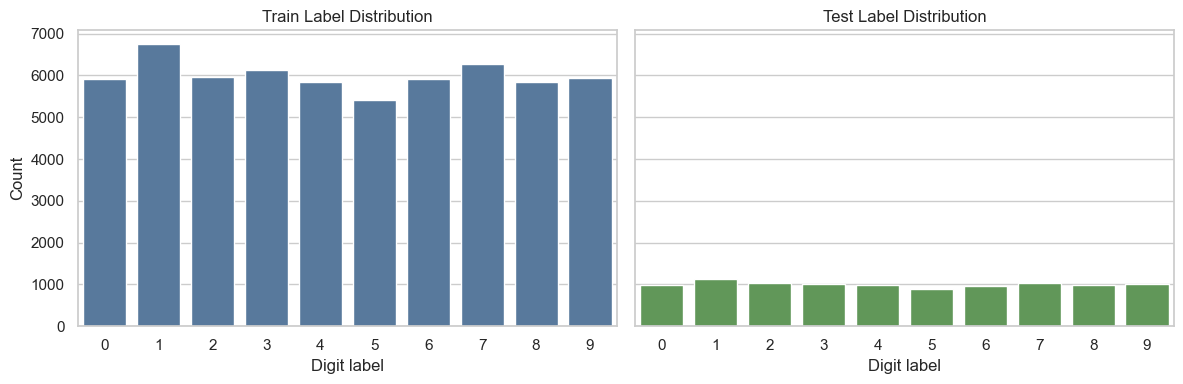

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], color="#4C78A8")
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Digit label")
axes[0].set_ylabel("Count")

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], color="#59A14F")
axes[1].set_title("Test Label Distribution")
axes[1].set_xlabel("Digit label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3) Merge Full Dataset and Check Overall Statistics

In [52]:
x_all, y_all = load_mnist(data_path)

print("Merged image array shape:", x_all.shape)
print("Merged label array shape:", y_all.shape)
print("Image dtype:", x_all.dtype)
print("Pixel range:", int(x_all.min()), "to", int(x_all.max()))
print("Number of unique labels:", np.unique(y_all).size)
print("Unique labels:", np.unique(y_all))

Merged image array shape: (70000, 28, 28)
Merged label array shape: (70000,)
Image dtype: uint8
Pixel range: 0 to 255
Number of unique labels: 10
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [53]:
overall_counts = pd.Series(y_all).value_counts().sort_index()
overall_df = pd.DataFrame({"count": overall_counts})
overall_df["percent"] = 100 * overall_df["count"] / overall_df["count"].sum()
overall_df

,count,percent
0,6903,9.861429
1,7877,11.252857
2,6990,9.985714
3,7141,10.201429
4,6824,9.748571
5,6313,9.018571
6,6876,9.822857
7,7293,10.418571
8,6825,9.750000
9,6958,9.940000


## 4) Visualize Samples as Images

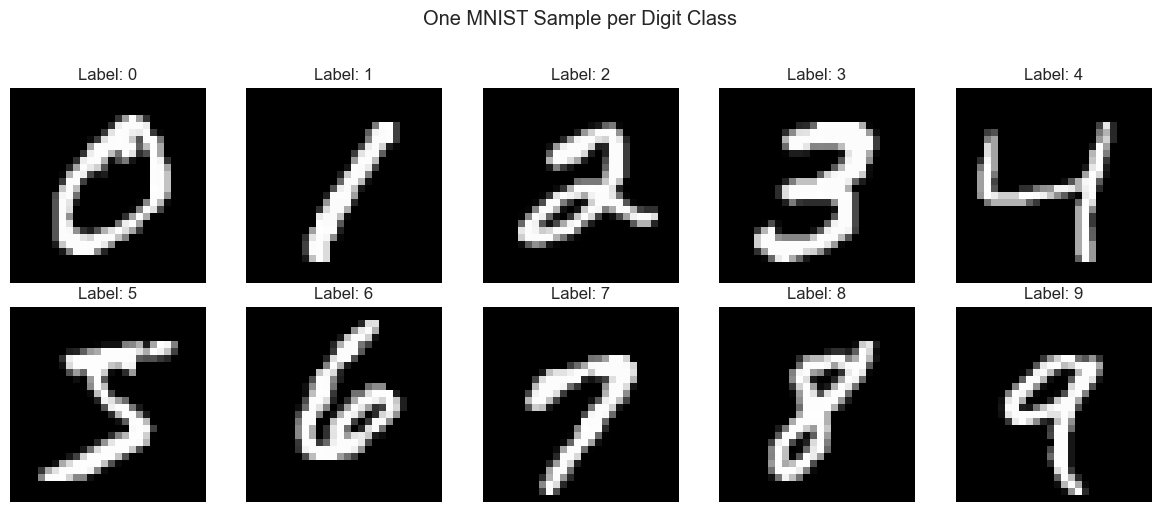

In [54]:
# One sample per digit label
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    idx = np.where(y_all == digit)[0][0]
    axes[digit].imshow(x_all[idx], cmap="gray")
    axes[digit].set_title(f"Label: {digit}")
    axes[digit].axis("off")

plt.suptitle("One MNIST Sample per Digit Class", y=1.02)
plt.tight_layout()
plt.show()

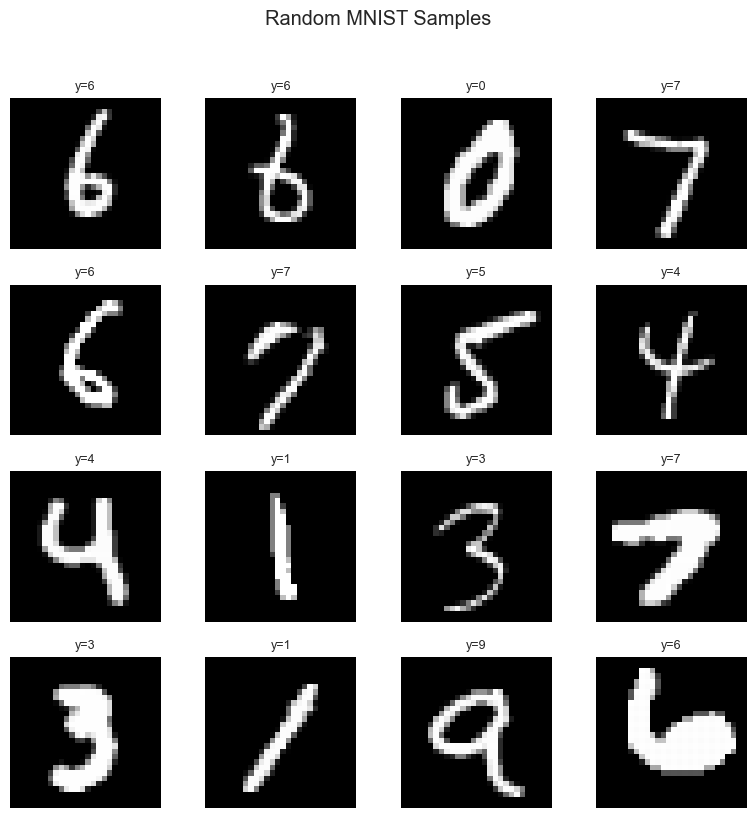

In [55]:
# Random samples from full dataset
rng = np.random.default_rng(42)
sample_ids = rng.choice(x_all.shape[0], size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, idx in zip(axes.ravel(), sample_ids):
    ax.imshow(x_all[idx], cmap="gray")
    ax.set_title(f"y={int(y_all[idx])}", fontsize=9)
    ax.axis("off")

plt.suptitle("Random MNIST Samples", y=1.02)
plt.tight_layout()
plt.show()

## 5) Pixel-Level Inspection

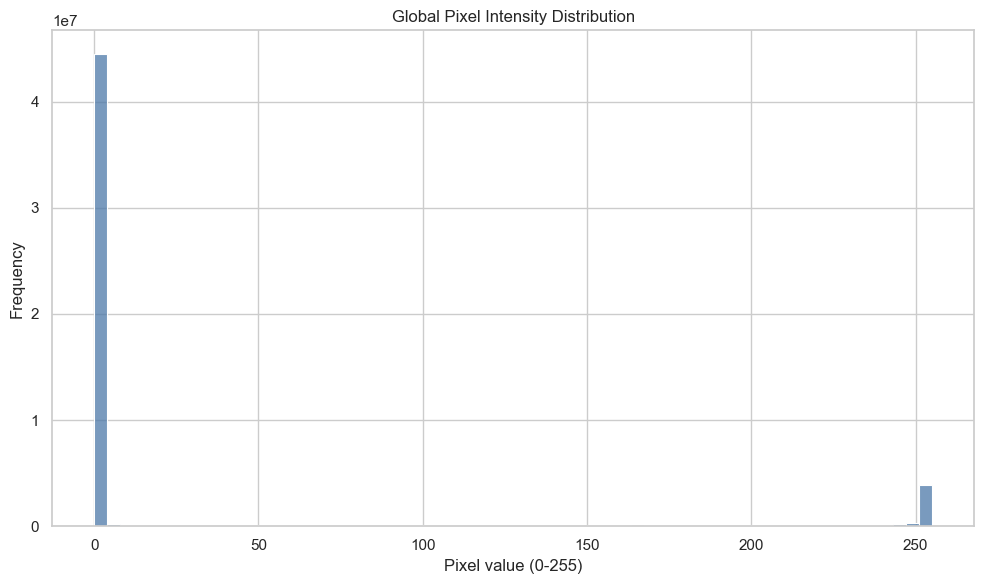

Pixel mean: 33.385964741253645
Pixel std: 78.6543736268941
Unique count: 256
First 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Last 20: [236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253
 254 255]


In [56]:
# Distribution of pixel intensities over all images
pixel_values = x_all.reshape(-1)

plt.figure(figsize=(10, 6))
sns.histplot(pixel_values, bins=64, color="#4C78A8")
plt.title("Global Pixel Intensity Distribution")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Pixel mean:", float(pixel_values.mean()))
print("Pixel std:", float(pixel_values.std()))

unique_vals = np.unique(pixel_values)
print("Unique count:", unique_vals.size)
print("First 20:", unique_vals[:20])
print("Last 20:", unique_vals[-20:])

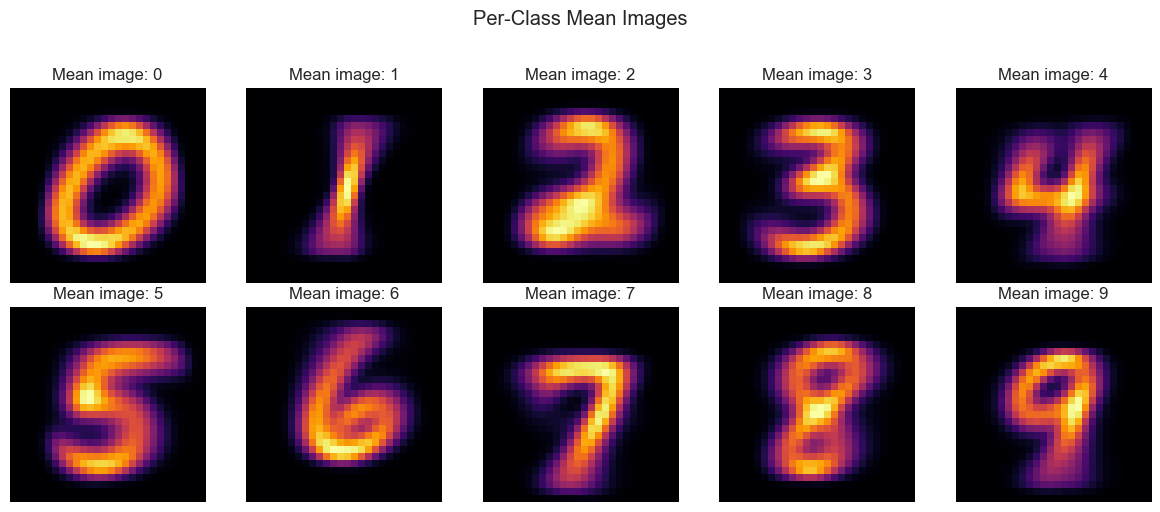

In [57]:
# Average image for each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    mean_img = x_all[y_all == digit].mean(axis=0)
    axes[digit].imshow(mean_img, cmap="inferno")
    axes[digit].set_title(f"Mean image: {digit}")
    axes[digit].axis("off")

plt.suptitle("Per-Class Mean Images", y=1.02)
plt.tight_layout()
plt.show()

## 9) Final Notes

This notebook now shows:
- raw file structure and all arrays
- label distributions in train/test and merged data
- sample images and per-class mean images
- pixel intensity statistics
- binary subset extraction
- exact train/validation/test split composition
- normalization, flattening, and HOG feature prep examples

In [58]:
class_a, class_b = 0, 1
x_binary, y_binary = select_binary_classes(x_all, y_all, class_a, class_b)

print(f"Binary classes: {class_a} vs {class_b}")
print("Binary image shape:", x_binary.shape)
print("Binary label shape:", y_binary.shape)
print("Counts:", pd.Series(y_binary).value_counts().sort_index().to_dict())

Binary classes: 0 vs 1
Binary image shape: (14780, 28, 28)
Binary label shape: (14780,)
Counts: {0: 6903, 1: 7877}


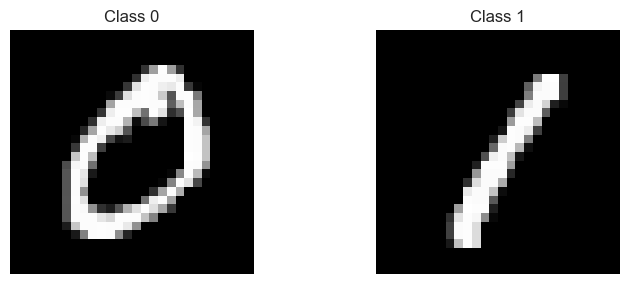

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, cls in enumerate([class_a, class_b]):
    idx = np.where(y_binary == cls)[0][0]
    axes[i].imshow(x_binary[idx], cmap="gray")
    axes[i].set_title(f"Class {cls}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 7) How Data Is Divided (Train/Validation/Test)

In [60]:
test_size = 0.2
val_size = 0.2
random_state = 42

x_train, y_train, x_val, y_val, x_test, y_test = split_data(
    x_binary,
    y_binary,
    test_size=test_size,
    val_size=val_size,
    random_state=random_state,
)

split_stats = pd.DataFrame(
    [
        {
            "split": "train",
            "samples": x_train.shape[0],
            "class_0": int((y_train == class_a).sum()),
            "class_1": int((y_train == class_b).sum()),
        },
        {
            "split": "validation",
            "samples": x_val.shape[0],
            "class_0": int((y_val == class_a).sum()),
            "class_1": int((y_val == class_b).sum()),
        },
        {
            "split": "test",
            "samples": x_test.shape[0],
            "class_0": int((y_test == class_a).sum()),
            "class_1": int((y_test == class_b).sum()),
        },
    ]
)
split_stats["class_0_pct"] = 100 * split_stats["class_0"] / split_stats["samples"]
split_stats["class_1_pct"] = 100 * split_stats["class_1"] / split_stats["samples"]
split_stats

,split,samples,class_0,class_1,class_0_pct,class_1_pct
0,train,8868,4105,4763,46.290032,53.709968
1,validation,2956,1396,1560,47.225981,52.774019
2,test,2956,1402,1554,47.428958,52.571042


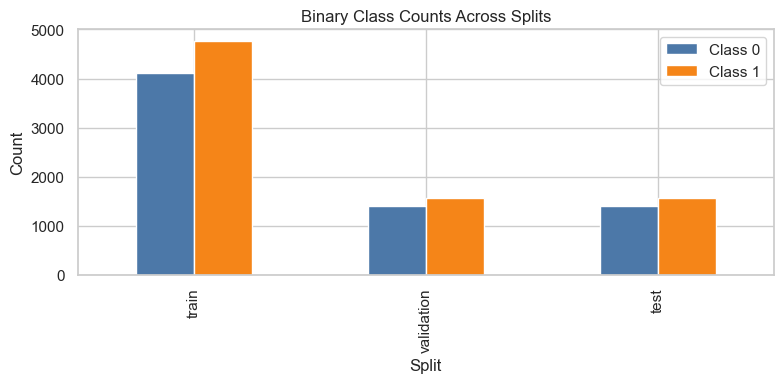

In [61]:
split_plot_df = split_stats.set_index("split")[["class_0", "class_1"]]
ax = split_plot_df.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518"])
ax.set_title("Binary Class Counts Across Splits")
ax.set_xlabel("Split")
ax.set_ylabel("Count")
ax.legend([f"Class {class_a}", f"Class {class_b}"])
plt.tight_layout()
plt.show()

## 8) Feature Preparation Extras

These examples summarize the data-prep steps used in the project helpers:
- normalize pixel values to `[0, 1]`
- flatten images for classical models
- create PCA feature sets for dimensionality reduction
- create HOG feature sets for experimentation
- show the same data can also be reused for multiclass work

In [62]:
# Normalize and prepare standardized flatten features via project helpers
x_train_norm = normalize_data(x_train)
x_val_norm = normalize_data(x_val)
x_test_norm = normalize_data(x_test)

x_train_flat, x_val_flat, x_test_flat = build_features(
    mode="flatten",
    x_train=x_train_norm,
    x_val=x_val_norm,
    x_test=x_test_norm,
)

print("Normalized train range:", float(x_train_norm.min()), "to", float(x_train_norm.max()))
print("Flattened train shape:", x_train_flat.shape)
print("Flattened validation shape:", x_val_flat.shape)
print("Flattened test shape:", x_test_flat.shape)

Normalized train range: 0.0 to 1.0
Flattened train shape: (8868, 784)
Flattened validation shape: (2956, 784)
Flattened test shape: (2956, 784)


In [63]:
# Prepare standardized HOG features via project helpers
x_train_hog, x_val_hog, x_test_hog = build_features(
    mode="hog",
    x_train=x_train_norm,
    x_val=x_val_norm,
    x_test=x_test_norm,
)

print("HOG train shape:", x_train_hog.shape)
print("HOG validation shape:", x_val_hog.shape)
print("HOG test shape:", x_test_hog.shape)

HOG train shape: (8868, 1296)
HOG validation shape: (2956, 1296)
HOG test shape: (2956, 1296)


In [70]:
# Prepare PCA features via project helper
x_train_pca = extract_pca_features(
    x_train_norm,
    n_components=0.95,
    random_state=42,
)
x_val_pca = extract_pca_features(
    x_val_norm,
    n_components=0.95,
    random_state=42,
)
x_test_pca = extract_pca_features(
    x_test_norm,
    n_components=0.95,
    random_state=42,
)

print("PCA train shape:", x_train_pca.shape)
print("PCA validation shape:", x_val_pca.shape)
print("PCA test shape:", x_test_pca.shape)

PCA train shape: (8868, 96)
PCA validation shape: (2956, 93)
PCA test shape: (2956, 93)


## 9) Final Notes

This notebook shows:
- raw file structure and all arrays
- label distributions in train/test and merged data
- sample images and per-class mean images
- pixel intensity statistics
- binary subset extraction
- exact train/validation/test split composition
- normalization, flattening, PCA, and HOG feature prep examples